In [9]:
import socket,warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings('ignore', category=ResourceWarning)
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")


import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq fastai 'ddgs>=6.2'
    !pip install --upgrade jupyter_client jupyter_core



# Defining functions to download images from DuckDuckGo

In [10]:
from ddgs import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images, safe_search='off')).itemgot('image')
import time, json

# Downloading Pictures of Ronaldo and Messi

In [20]:
from fastdownload import download_url
from fastai.vision.all import *
#Ronaldo
download_url(search_images('Cristiano Ronaldo soccer', max_images=1)[0], 'ronaldo.jpg', show_progress=False)
#Messi
download_url(search_images('Lionel Messi soccer', max_images=1)[0], 'messi.jpg', show_progress=False)

Path('messi.jpg')

# Ronaldo Picture

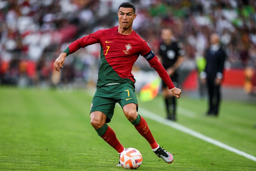

In [21]:
Image.open('ronaldo.jpg').to_thumb(256,256)

# Messi Picture

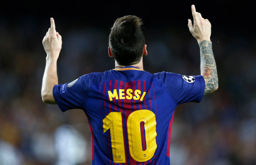

In [22]:
Image.open('messi.jpg').to_thumb(256,256)

# Scraping more photos of Ronaldo and Messi

In [23]:
searches = 'Cristiano Ronaldo','Lionel Messi'
path = Path('ronaldo_or_messi')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


# Eliminating Failed Pictures

In [28]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

# Initializing Training Set

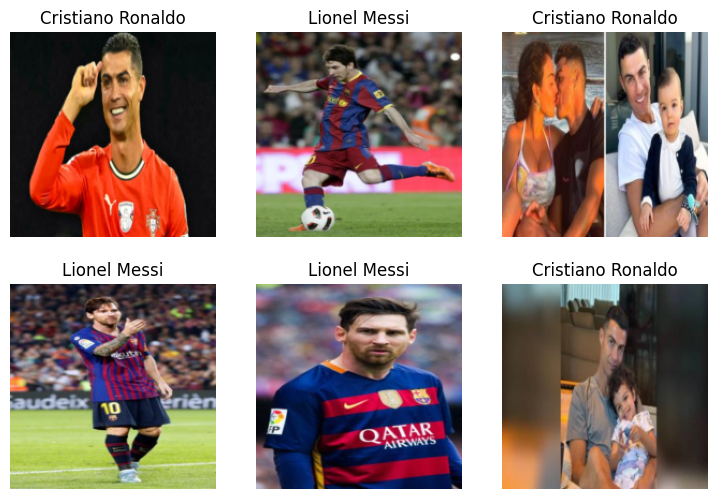

In [39]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

# Training Model with visual_learner method

In [40]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.120317,1.455106,0.425000,00:01


epoch,train_loss,valid_loss,error_rate,time
0,0.548508,0.747992,0.250000,00:01
1,0.299715,0.574240,0.125000,00:01
2,0.209529,0.438451,0.125000,00:01


# Model Results

In [43]:
#Ronaldo
is_ronaldo,_,probs = learn.predict(PILImage.create('ronaldo.jpg'))
print(f"This is a: {is_ronaldo}.")
print(f"Probability it's a ronaldo: {probs[0]:.4f}")

This is a: Cristiano Ronaldo.
Probability it's a ronaldo: 1.0000


In [ ]:
#Messi
is_messi,_,probs = learn.predict(PILImage.create('messi.jpg'))
print(f"This is a {is_messi}")
print(f"Probability that it's a messi: {probs[0]:.4f}")